# Multilayer graph modeling of gene expression data

In this notebook you will find the code to replicate the experiments for the multilayer graph gene classification.

If you wish to apply the code to your own data, please refer to the pipeline script.

*note*: it will be necessary to change pathways and computer-specific variables so that the code will work properly.

# Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from pathlib import Path
import mygene
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from scipy import stats
from scipy.stats import pearsonr 
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
from sklearn.metrics import make_scorer
from lightgbm import LGBMRegressor
from sklearn.utils import shuffle
import ast
from statsmodels.stats.multitest import multipletests
from scipy.stats import spearmanr
from scipy.stats import ttest_ind
import torch
from tqdm import tqdm
import torch.nn as nn
from ast import literal_eval
from xgboost import XGBClassifier
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
import pickle
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv, GATv2Conv, global_mean_pool
from torch_geometric.data import Data
import random
from torch.nn import Linear, GELU, Sequential, BatchNorm1d, Dropout
from torch_geometric.nn import (
    GINEConv, JumpingKnowledge,
    global_mean_pool, global_max_pool
)
from copy import deepcopy
import networkx as nx
from matplotlib import cm
from torch_geometric.utils import to_networkx
from matplotlib.patches import Patch

# Setup

### Change here all directories and paramenters according to your settings

In [15]:
"""
PARAMETERS TO MODIFY

this code is implemented such that, once you adjust these parameters, you can launch all the code
"""
# ==== Device ====
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# === GENERAL PARAMETERS ===

#select the cell line:
cell_line = "E003"
#cell_line = "E066"
#cell_line = "E116"

# ======================

# === GNN PARAMETERS ===
np.random.seed(42)
torch.manual_seed(42)

hidden_channels = 256
num_layers      = 2
dropout_p       = 0.30
batch_size      = 64
lr              = 1e-4
weight_decay    = 5e-5
num_folds       = 4
max_epochs      = 30
early_patience  = 20           
val_frac        = 0.15
dropedge_p      = 0.1         
clip_grad_norm  = 1.0
# ===================

# Get data and data formatting

In [3]:
final_df = pd.read_csv("C:/Users/stefa/OneDrive/Desktop/geni_pulito_E003.csv") 
# final_df = pd.read_csv("C:/Users/stefa/OneDrive/Desktop/geni_pulito_E066.csv") 
#final_df = pd.read_csv("C:/Users/stefa/OneDrive/Desktop/geni_pulito_E116.csv") 

In [4]:
df = pd.read_csv("C:/Users/stefa/OneDrive/Desktop/geni_matrice.csv") 
#df = pd.read_csv("C:/Users/stefa/OneDrive/Desktop/geni_matrice_E066.csv") 
#df = pd.read_csv("C:/Users/stefa/OneDrive/Desktop/geni_matrice_E116.csv") 

df['expression'] = df['expression'].round().astype(int)

features_df = pd.read_csv("features_epigenetiche_per_gene.csv")
#features_df = pd.read_csv("features_epigenetiche_per_gene_E066.csv")
#features_df = pd.read_csv("features_epigenetiche_per_gene_E116.csv")
features_df

,node,gene_type,H3K4me1_f0,H3K4me1_f1,H3K4me1_f2,H3K4me1_f3,H3K4me1_f4,H3K4me1_f5,H3K4me1_f6,H3K4me1_f7,...,H3K9me3_f90,H3K9me3_f91,H3K9me3_f92,H3K9me3_f93,H3K9me3_f94,H3K9me3_f95,H3K9me3_f96,H3K9me3_f97,H3K9me3_f98,H3K9me3_f99
0,27286,co-expressed,-0.079440,0.089178,-0.084707,0.071066,-0.033926,0.056653,-0.095329,-0.002077,...,0.223780,0.047975,-0.091142,-0.021581,-0.065496,-0.216318,0.006111,0.109385,0.007221,0.042114
1,7105,main,-0.077425,0.035563,-0.075661,0.017960,-0.050275,0.070010,-0.119184,0.003596,...,0.096893,-0.138565,-0.219266,0.149191,0.029670,-0.189808,-0.027112,0.130762,-0.065570,0.106253
2,1266,co-expressed,-0.149155,0.143370,-0.125348,0.017255,0.044921,0.035654,-0.451051,-0.132123,...,0.175289,-0.462186,-0.446254,0.354082,-0.069563,-0.516342,-0.100647,0.153623,-0.108377,0.298764
3,27018,co-expressed,-0.099207,0.058637,-0.060810,0.014431,-0.034697,0.028557,-0.099090,0.001079,...,0.122715,-0.063326,-0.172531,0.085976,0.033317,-0.114747,-0.022276,0.167155,-0.048773,0.100348
4,4886,co-expressed,-0.103617,0.064496,-0.051016,0.025089,-0.041889,0.024492,-0.099666,0.026464,...,0.185825,-0.041064,-0.164430,0.080081,-0.045825,-0.232819,-0.050230,0.120589,0.023655,0.093377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13431,51174,co-expressed,-0.094645,0.074262,-0.063492,0.030053,-0.028941,0.023321,-0.092151,0.004214,...,0.171928,-0.030058,-0.169699,0.101775,-0.036879,-0.253075,-0.092571,0.048491,0.039677,0.004707
13432,5222,main,-0.041259,0.066413,-0.034512,0.040231,-0.038604,0.027626,-0.094155,-0.000218,...,0.142531,0.048780,-0.107439,0.026139,0.013423,-0.124671,-0.027678,0.057335,0.040614,-0.073734
13433,154288,co-expressed,-0.091746,-0.065662,-0.124170,0.074627,-0.075080,0.141151,-0.309071,-0.000592,...,0.193059,0.059226,-0.151491,0.019695,-0.001610,-0.162455,-0.050077,0.139834,0.059116,-0.015958
13434,100129128,main,-0.083049,0.080254,-0.080037,0.021812,-0.010977,0.038130,-0.089633,-0.018537,...,0.172559,0.029716,-0.138319,0.023690,0.005412,-0.167141,-0.047191,0.111668,0.030633,-0.020513


In [ ]:
#USE THIS CHUNK ONLY FOR E116 

#features_df = features_df.rename(columns={"node": "entrez_id"})

#features_df["entrez_id"] = features_df["entrez_id"].astype(str).str.replace("_aggregate", "", regex=False)
#features_df

In [5]:
features_df['entrez_id'] = features_df['node'].astype(str)
features_df = features_df.drop(columns="gene_type")

df_unique = df.drop_duplicates(subset='entrez_id').copy()
df_unique['entrez_id'] = df_unique['entrez_id'].astype(str)

merged_df = pd.merge(df_unique, features_df, on='entrez_id', how='inner')
merged_df

,gene_id,expression,eid,label,chrom,start,end,strand,split,neighbors,...,H3K9me3_f90,H3K9me3_f91,H3K9me3_f92,H3K9me3_f93,H3K9me3_f94,H3K9me3_f95,H3K9me3_f96,H3K9me3_f97,H3K9me3_f98,H3K9me3_f99
0,ENSG00000000003,44,E003,1,chrX,99891803,99891804,-,4,NaN,...,0.096893,-0.138565,-0.219266,0.149191,0.029670,-0.189808,-0.027112,0.130762,-0.065570,0.106253
1,ENSG00000000005,2,E003,0,chrX,99839931,99839932,+,4,NaN,...,0.129602,0.042729,-0.117599,0.042401,0.015104,-0.132821,-0.035597,0.071426,0.020868,-0.024360
2,ENSG00000000457,3,E003,0,chr1,169863037,169863038,-,1,chr1:170616799-170620074;chr1:170575489-170580...,...,0.193079,-0.118917,-0.230074,0.217112,-0.109970,-0.420660,-0.152954,-0.040019,0.043408,0.058393
3,ENSG00000000460,7,E003,1,chr1,169764179,169764180,+,1,chr1:169497108-169500425;chr1:169590775-169597...,...,0.165328,-0.155847,-0.276086,0.235031,-0.075027,-0.389749,-0.145259,0.053030,0.004916,0.115835
4,ENSG00000000938,0,E003,0,chr1,27953108,27953109,-,1,chr1:27383252-27390061;chr1:27744472-27751372;...,...,0.299000,0.012823,-0.188857,-0.045220,-0.038449,-0.261751,-0.042925,0.124743,0.061450,-0.035571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11811,ENSG00000258818,2,E003,0,chr14,21152717,21152718,+,1,chr14:21127322-21131085;chr14:21089191-2109805...,...,0.251515,-0.063413,-0.223180,0.258068,-0.164007,-0.497543,-0.223333,-0.057026,0.120652,0.068362
11812,ENSG00000258839,1,E003,0,chr16,89985268,89985269,+,3,chr16:90050224-90062361;chr16:89878245-8989408...,...,0.251122,-0.038579,-0.260169,0.088392,-0.075848,-0.359521,-0.081095,0.161317,0.050646,0.105802
11813,ENSG00000258890,26,E003,1,chr17,62503093,62503094,+,4,chr17:62471061-62475206;chr17:62475207-6247940...,...,0.413388,-0.270492,-0.330205,0.494373,-0.439320,-0.992795,-0.397149,-0.234153,0.181422,0.245008
11814,ENSG00000258947,35,E003,1,chr16,89988331,89988332,+,3,chr16:90050224-90062361;chr16:89878245-8989408...,...,0.222226,-0.076826,-0.241238,0.103674,-0.052379,-0.311432,-0.061253,0.143151,0.025180,0.114340


In [6]:
final_df = merged_df

# Classification - XGBoost

In [ ]:
X = []
y = []
splits = []

histone_cols = [col for col in final_df.columns if any(mark in col for mark in [
    "H3K4me1", "H3K4me3", "H3K9ac", "H3K27ac", "H3K27me3", "H3K36me3", "H3K9me3"
])]

for idx, row in final_df.iterrows():
    raw_matrix = row['matrice_correlazioni']

    try:
        # Parsing matrice
        if isinstance(raw_matrix, str):
            matrice = ast.literal_eval(raw_matrix)
        elif isinstance(raw_matrix, list):
            matrice = raw_matrix
        else:
            continue

        if not (isinstance(matrice, list) and all(isinstance(r, list) for r in matrice)):
            continue

        # Flatten correlation matrix
        matrice_flattened = np.array(matrice).flatten()

        # extract features
        histone_features = row.loc[histone_cols].astype(float).values

        # concatenation
        features = np.concatenate([matrice_flattened, histone_features])

        X.append(features)
        y.append(row['label'])
        splits.append(row['split'])

    except Exception as e:
        print(f"⚠️ Error at row {idx}: {e}")
        continue

# final conversion
X = np.array(X)
y = np.array(y)
splits = np.array(splits)

In [ ]:
X = []
y = []
splits = []

histone_cols = [col for col in final_df.columns if any(mark in col for mark in [
    "H3K4me1", "H3K4me3", "H3K9ac", "H3K27ac", "H3K27me3", "H3K36me3", "H3K9me3"
])]

def get_histone_features(entrez_id):
    row_feat = features_df[features_df['entrez_id'] == entrez_id]
    if row_feat.empty:
        return None
    return row_feat[histone_cols].values.flatten()

for idx, row in final_df.iterrows():
    raw_matrix = row['matrice_correlazioni']

    try:
        
        if isinstance(raw_matrix, str):
            matrice = ast.literal_eval(raw_matrix)
        elif isinstance(raw_matrix, list):
            matrice = raw_matrix
        else:
            continue

        if not (isinstance(matrice, list) and all(isinstance(r, list) for r in matrice)):
            continue

        
        matrice_flattened = np.array(matrice).flatten()

        
        gene_feature_vectors = []

        #main gene
        main_id = str(row['entrez_id'])
        main_feats = get_histone_features(main_id)
        if main_feats is not None:
            gene_feature_vectors.append(main_feats)

        # Gene coexèpressed
        coexpr = row.get('co-espressione', '')
        if isinstance(coexpr, str):
            for g in coexpr.split(','):
                g = g.strip()
                if not g:
                    continue
                co_feats = get_histone_features(g)
                if co_feats is not None:
                    gene_feature_vectors.append(co_feats)

        if not gene_feature_vectors:
            continue

        # concatenation all features
        histone_features = np.concatenate(gene_feature_vectors)

        # final concatenation: [matrice_correlazione | histone_features]
        features = np.concatenate([matrice_flattened, histone_features])
        
        # dataset
        X.append(features)
        y.append(row['label'])
        splits.append(row['split'])

    except Exception as e:
        print(f"⚠️ Error at row {idx}: {e}")
        continue

# Conversione finale in array numpy
X = np.array(X)
y = np.array(y)
splits = np.array(splits)

In [22]:
X.shape

(11815, 3584)

In [ ]:
# XGBoost classifier definition
xgb_clf = XGBClassifier(
    n_estimators=500, 
    max_depth=5,
    eval_metric='logloss',
    random_state=42
)

# Cross-Validation
xgb_scores = []
xgb_auc_scores = []
xgb_precision_scores = []
xgb_recall_scores = []
xgb_f1_scores = []

for fold in range(1, 5):
    test_idx = np.where(splits == fold)[0]
    train_idx = np.where(splits != fold)[0]
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    xgb_clf.fit(X_train, y_train)
    y_pred = xgb_clf.predict(X_test)
    y_prob = xgb_clf.predict_proba(X_test)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    xgb_scores.append(acc)
    
    # AUC score
    if len(np.unique(y)) == 2:
        auc = roc_auc_score(y_test, y_prob[:, 1])
    else:
        auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
    xgb_auc_scores.append(auc)
    
    # Precision
    precision = precision_score(y_test, y_pred, average='binary' if len(np.unique(y)) == 2 else 'macro')
    xgb_precision_scores.append(precision)
    
    # Recall
    recall = recall_score(y_test, y_pred, average='binary' if len(np.unique(y)) == 2 else 'macro')
    xgb_recall_scores.append(recall)
    
    # F1 Score
    f1 = f1_score(y_test, y_pred, average='binary' if len(np.unique(y)) == 2 else 'macro')
    xgb_f1_scores.append(f1)

# Print the results
print("XGBoost Cross-Validation Accuracy Scores:", xgb_scores)
print("XGBoost Mean Accuracy:", np.mean(xgb_scores))

print("XGBoost Cross-Validation AUC Scores:", xgb_auc_scores)
print("XGBoost Mean AUC:", np.mean(xgb_auc_scores))

print("XGBoost Cross-Validation Precision Scores:", xgb_precision_scores)
print("XGBoost Mean Precision:", np.mean(xgb_precision_scores))

print("XGBoost Cross-Validation Recall Scores:", xgb_recall_scores)
print("XGBoost Mean Recall:", np.mean(xgb_recall_scores))

print("XGBoost Cross-Validation F1 Scores:", xgb_f1_scores)
print("XGBoost Mean F1:", np.mean(xgb_f1_scores))

XGBoost Cross-Validation Accuracy Scores: [0.9158291457286433, 0.910752688172043, 0.9190927555856466, 0.9037062694838933]
XGBoost Mean Accuracy: 0.9123452147425566
XGBoost Cross-Validation AUC Scores: [0.9669884620514873, 0.9666923314497993, 0.9675208742722312, 0.9519247596276137]
XGBoost Mean AUC: 0.9632816068502829
XGBoost Cross-Validation Precision Scores: [0.9325153374233128, 0.9210977701543739, 0.934640522875817, 0.9184692179700499]
XGBoost Mean Precision: 0.9266807121058884
XGBoost Cross-Validation Recall Scores: [0.9306122448979591, 0.9355400696864111, 0.935149863760218, 0.9266927811975377]
XGBoost Mean Recall: 0.9319987398855315
XGBoost Cross-Validation F1 Scores: [0.9315628192032687, 0.9282627484874676, 0.9348951239444293, 0.9225626740947075]
XGBoost Mean F1: 0.9293208414324683


## T-test

In [2]:
final_df = pd.read_csv("C:/Users/stefa/OneDrive/Desktop/geni_matrice.csv") 
#final_df = pd.read_csv("C:/Users/stefa/OneDrive/Desktop/geni_matrice_E066.csv") 
#final_df = pd.read_csv("C:/Users/stefa/OneDrive/Desktop/geni_matrice_E116.csv") 


#final_df = pd.read_csv("C:/Users/stefa/OneDrive/Desktop/final_df_E116_ultimi_coexp.csv") 

In [3]:
# Estrai le matrici e le label
X = []
labels = []

for _, row in final_df.iterrows():
    try:
        matrice = ast.literal_eval(row['matrice_correlazioni'])
        if isinstance(matrice, list) and all(isinstance(r, list) for r in matrice):
            arr = np.array(matrice)
            if arr.shape == (28, 28):
                X.append(arr)
                labels.append(row['label'])
    except:
        continue

X = np.array(X)
labels = np.array(labels)

# Controlli di base
if X.ndim != 3 or X.shape[0] < 2 or len(np.unique(labels)) < 2:
    raise ValueError("Dati insufficienti o malformati")

# Divisione in gruppi
group0 = X[labels == 0]
group1 = X[labels == 1]

# T-test elemento per elemento (escludendo la diagonale)
t_stats = np.zeros((28, 28))
p_values = np.ones((28, 28))

for i in range(28):
    for j in range(28):
        if i == j:
            continue  # Salta la diagonale
        try:
            vals0 = group0[:, i, j]
            vals1 = group1[:, i, j]
            stat, p = ttest_ind(vals0, vals1, equal_var=False)
            t_stats[i, j] = stat
            p_values[i, j] = p
        except:
            continue

# Correzione multipla
p_flat = p_values.flatten()
_, p_adj_flat, _, _ = multipletests(p_flat, method='fdr_bh')
p_adj = p_adj_flat.reshape(28, 28)

# Imposta la diagonale a NaN per evitare disturbo nella heatmap
for i in range(28):
    p_adj[i, i] = np.nan

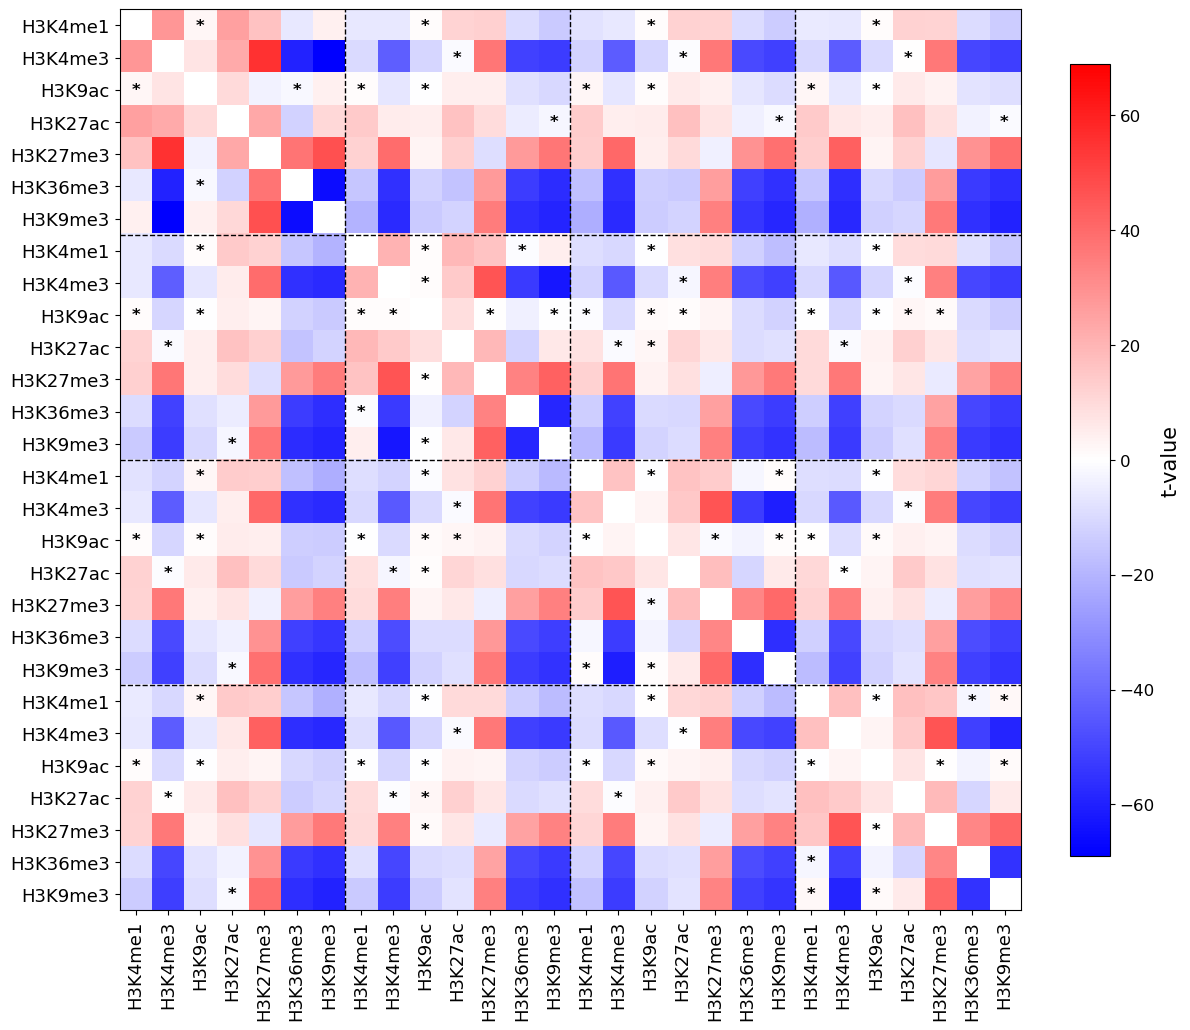

In [4]:
# 1) Diagonale a NaN
np.fill_diagonal(t_stats, np.nan)

# 2) Normalizzazione simmetrica
abs_max = np.nanmax(np.abs(t_stats))
norm = TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)

# 3) Colormap blu-bianco-rosso
custom_cmap = LinearSegmentedColormap.from_list(
    "custom_red_white_blue", ["blue", "white", "red"]
)

# 4) Etichette istone (ripetute per ogni blocco da 7)
modifiche_istone = ["H3K4me1", "H3K4me3", "H3K9ac",
                    "H3K27ac", "H3K27me3", "H3K36me3", "H3K9me3"]
n_mod = len(modifiche_istone)
n_geni = 28 // n_mod
tick_labels = modifiche_istone * n_geni  # 7 etichette ripetute 4 volte

# 5) Plot
fig, ax = plt.subplots(figsize=(12, 12))  # grande per leggere bene le label
im = ax.imshow(t_stats, cmap=custom_cmap, norm=norm)

# 6) Colorbar con label grande
# 6) Colorbar più piccola
cbar = plt.colorbar(im, ax=ax, fraction=0.04, shrink=0.8, pad=0.05)
cbar.set_label('t-value', fontsize=15)
cbar.ax.tick_params(labelsize=12)

# 7) Tick + etichette come nel tuo seaborn
ax.set_xticks(range(28))
ax.set_yticks(range(28))
ax.set_xticklabels(tick_labels, rotation=90, fontsize=13)
ax.set_yticklabels(tick_labels, rotation=0, fontsize=13)

# 8) Asterischi dove p_adj ≥ 0.01
for i in range(28):
    for j in range(28):
        if i != j and p_adj[i, j] >= 0.01:
            ax.text(j, i, '*', ha='center', va='center',
                    color='black', fontsize=12, fontweight='bold')

# 9) Linee tratteggiate ogni 7 per separare i blocchi
for k in range(1, n_geni):
    ax.axvline(x=n_mod * k - 0.5, color='black', linestyle='--', lw=1)
    ax.axhline(y=n_mod * k - 0.5, color='black', linestyle='--', lw=1)

plt.tight_layout()
plt.show()

### permutation test

In [ ]:
N_PERM = 1000
rng = np.random.default_rng(42)

iu = np.triu_indices(28, k=1)

obs_mean = np.nanmean(np.abs(t_stats[iu]))

# null distribution
null_mean = np.empty(N_PERM)

for b in range(N_PERM):
    perm = rng.permutation(labels)
    gp0 = X[perm == 0]
    gp1 = X[perm == 1]

    t_vals = []
    for i, j in zip(*iu):
        vals0 = gp0[:, i, j]
        vals1 = gp1[:, i, j]
        tt, _ = ttest_ind(vals0, vals1, equal_var=False)
        t_vals.append(abs(tt))

    null_mean[b] = np.nanmean(t_vals)

# p-value
p_val = (1 + np.sum(null_mean >= obs_mean)) / (N_PERM + 1)
print(f"Permutation p-value (mean|t|) = {p_val:.4g}")

plt.figure(figsize=(7,5))
plt.hist(null_mean, bins=40, color='lightgray', edgecolor='black')
plt.axvline(obs_mean, color='red', lw=2, ls='--',
            label=f'Observed = {obs_mean:.3f}  (p = {p_val:.2g})')
q95 = np.quantile(null_mean, 0.95)
plt.axvline(q95, color='blue', ls=':',
            label=f'95% thr = {q95:.3f}')
plt.xlabel('mean |t| under permutation', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Frobenius reconstruction residual 

In [ ]:
df = pd.read_csv("C:/Users/stefa/OneDrive/Desktop/geni_matrice.csv") 
#df = pd.read_csv("C:/Users/stefa/OneDrive/Desktop/geni_matrice_E066.csv") 
#df = pd.read_csv("C:/Users/stefa/OneDrive/Desktop/geni_matrice_E116.csv") 

df

In [ ]:
features_df = pd.read_csv("features_epigenetiche_per_gene.csv")
#features_df = pd.read_csv("features_epigenetiche_per_gene_E066.csv")
#features_df = pd.read_csv("features_epigenetiche_per_gene_E116.csv")
features_df

In [ ]:
import numpy as np
import pandas as pd
import ast
import re
from scipy.stats import ttest_ind, mannwhitneyu

# ------------------------------------------------------------
# Safe parser for stored matrices
# ------------------------------------------------------------
def parse_mat_safe(x):
    if x is None:
        return None
    if isinstance(x, float) and np.isnan(x):
        return None
    if isinstance(x, np.ndarray):
        return x.astype(np.float64) if x.ndim == 2 else None
    if isinstance(x, (list, tuple)):
        try:
            arr = np.array(x, dtype=np.float64)
            return arr if arr.ndim == 2 else None
        except Exception:
            return None
    if not isinstance(x, str):
        return None

    s = x.strip()
    if len(s) == 0:
        return None

    s = re.sub(r'\bNaN\b|\bnan\b', 'None', s)
    s = re.sub(r'\bInfinity\b|\binf\b', '1e309', s)
    s = re.sub(r'\b-Infinity\b|\b-inf\b', '-1e309', s)

    try:
        obj = ast.literal_eval(s)
        arr = np.array(obj, dtype=np.float64)
        return arr if arr.ndim == 2 else None
    except Exception:
        return None


# ------------------------------------------------------------
# Extract first (L+1) layers from a full matrix built with max_L
# Example: full 28x28 from L=3 -> extract 14x14 for L=1
# ------------------------------------------------------------
def extract_submatrix_for_L(A_full, L_new, n_marks=7, max_L=3):
    """
    A_full: adjacency matrix built with max_L partners
    L_new: desired number of co-expressed partners (e.g. 1 or 2)
    n_marks: number of histone marks per layer
    max_L: original number of partners used in A_full (here 3)

    Assumes layer order:
        [target, coexpr_1, coexpr_2, ..., coexpr_max_L]
    """
    expected_full_shape = ((max_L + 1) * n_marks, (max_L + 1) * n_marks)
    if A_full.shape != expected_full_shape:
        raise ValueError(f"Expected full shape {expected_full_shape}, got {A_full.shape}")

    n_layers_new = L_new + 1
    new_size = n_layers_new * n_marks
    return A_full[:new_size, :new_size]


# ------------------------------------------------------------
# Utilities
# ------------------------------------------------------------
def block_view(A, n_layers=4, n_marks=7):
    blocks = []
    for u in range(n_layers):
        row_blocks = []
        ru = slice(u * n_marks, (u + 1) * n_marks)
        for v in range(n_layers):
            cv = slice(v * n_marks, (v + 1) * n_marks)
            row_blocks.append(A[ru, cv])
        blocks.append(row_blocks)
    return blocks


# ------------------------------------------------------------
# Best strong-product approximation with complete inter-layer graph
# ------------------------------------------------------------
def best_strong_product_complete(A, n_layers=4, n_marks=7, symmetrize=True, zero_diag=True):
    A = np.asarray(A, dtype=np.float64)

    expected_shape = (n_layers * n_marks, n_layers * n_marks)
    if A.shape != expected_shape:
        raise ValueError(f"Expected shape {expected_shape}, got {A.shape}")

    A = A.copy()

    if symmetrize:
        A = 0.5 * (A + A.T)

    if zero_diag:
        np.fill_diagonal(A, 0.0)

    I_M = np.eye(n_marks)
    blocks = block_view(A, n_layers=n_layers, n_marks=n_marks)

    diag_blocks = []
    off_blocks_minus_I = []

    for u in range(n_layers):
        for v in range(n_layers):
            B = blocks[u][v]
            if u == v:
                diag_blocks.append(B)
            else:
                off_blocks_minus_I.append(B - I_M)

    numerator = np.sum(diag_blocks, axis=0) + np.sum(off_blocks_minus_I, axis=0)
    denominator = len(diag_blocks) + len(off_blocks_minus_I)
    A_M_hat = numerator / denominator

    if symmetrize:
        A_M_hat = 0.5 * (A_M_hat + A_M_hat.T)

    if zero_diag:
        np.fill_diagonal(A_M_hat, 0.0)

    A_sp = np.zeros_like(A)
    for u in range(n_layers):
        ru = slice(u * n_marks, (u + 1) * n_marks)
        for v in range(n_layers):
            cv = slice(v * n_marks, (v + 1) * n_marks)
            if u == v:
                A_sp[ru, cv] = A_M_hat
            else:
                A_sp[ru, cv] = I_M + A_M_hat

    residual_matrix = A - A_sp
    abs_residual = np.linalg.norm(residual_matrix, ord="fro")
    norm_A = np.linalg.norm(A, ord="fro")
    rel_residual = abs_residual / norm_A if norm_A > 0 else np.nan

    return {
        "A_input": A,
        "A_sp": A_sp,
        "A_M_hat": A_M_hat,
        "residual_matrix": residual_matrix,
        "abs_residual": abs_residual,
        "rel_residual": rel_residual,
    }


# ------------------------------------------------------------
# Apply to dataframe for desired L
# ------------------------------------------------------------
def compute_strong_product_residuals_from_full_L3(
    df,
    matrix_col="matrice_correlazioni",
    label_col="label",
    L_new=1,
    n_marks=7,
    max_L=3,
    symmetrize=True,
    zero_diag=True,
):
    """
    Uses matrices already computed with L=3 and extracts the first L_new+1 layers.
    """
    results = []
    n_layers_new = L_new + 1

    for idx, row in df.iterrows():
        A_full = parse_mat_safe(row[matrix_col])
        if A_full is None:
            continue

        try:
            A_sub = extract_submatrix_for_L(A_full, L_new=L_new, n_marks=n_marks, max_L=max_L)

            fit = best_strong_product_complete(
                A_sub,
                n_layers=n_layers_new,
                n_marks=n_marks,
                symmetrize=symmetrize,
                zero_diag=zero_diag,
            )

            results.append({
                "index": idx,
                "label": int(row[label_col]),
                "L": L_new,
                "strong_abs_residual": fit["abs_residual"],
                "strong_rel_residual": fit["rel_residual"],
                "A_sub": A_sub,
                "A_sp": fit["A_sp"],
                "A_M_hat": fit["A_M_hat"],
                "residual_matrix": fit["residual_matrix"],
            })

        except Exception as e:
            print(f"Skipping row {idx} because of error: {e}")

    return pd.DataFrame(results)




residual_df_L1 = compute_strong_product_residuals_from_full_L3(
    df,
    matrix_col="matrice_correlazioni",
    label_col="label",
    L_new=1,
    n_marks=7,
    max_L=3,
    symmetrize=True,
    zero_diag=True,
)

print("Numero matrici usate (L=1):", len(residual_df_L1))
display(residual_df_L1.head())

In [ ]:
residual_df_L2 = compute_strong_product_residuals_from_full_L3(
    df,
    matrix_col="matrice_correlazioni",
    label_col="label",
    L_new=2,
    n_marks=7,
    max_L=3,
    symmetrize=True,
    zero_diag=True,
)

In [ ]:
residual_df_L3 = compute_strong_product_residuals_from_full_L3(
    df,
    matrix_col="matrice_correlazioni",
    label_col="label",
    L_new=3,
    n_marks=7,
    max_L=3,
    symmetrize=True,
    zero_diag=True,
)

In [ ]:
h0 = residual_df_L3.loc[residual_df_L3["label"] == 0, "strong_rel_residual"].dropna().to_numpy()
h1 = residual_df_L3.loc[residual_df_L3["label"] == 1, "strong_rel_residual"].dropna().to_numpy()

print(f"H0: n = {len(h0)}, mean = {np.mean(h0):.6f}, std = {np.std(h0, ddof=1):.6f}")
print(f"H1: n = {len(h1)}, mean = {np.mean(h1):.6f}, std = {np.std(h1, ddof=1):.6f}")

t_stat, p_ttest = ttest_ind(h0, h1, equal_var=False)
u_stat, p_mwu = mannwhitneyu(h0, h1, alternative="two-sided")

def cohens_d(x, y):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    nx, ny = len(x), len(y)
    vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)
    pooled_std = np.sqrt(((nx - 1) * vx + (ny - 1) * vy) / (nx + ny - 2))
    if pooled_std == 0:
        return np.nan
    return (np.mean(x) - np.mean(y)) / pooled_std

d = cohens_d(h0, h1)

print(f"Welch t-test:   t = {t_stat:.6f}, p = {p_ttest:.6e}")
print(f"Mann-Whitney:   U = {u_stat:.6f}, p = {p_mwu:.6e}")
print(f"Cohen's d = {d:.6f}")

# Sensitivity Analysis on L = 1,2,3

In [ ]:
import numpy as np
import pandas as pd
import ast
import re

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

# ============================================================
# 1) parser matrice
# ============================================================
def parse_mat_safe(x):
    if x is None:
        return None
    if isinstance(x, float) and np.isnan(x):
        return None
    if isinstance(x, np.ndarray):
        return x.astype(np.float64) if x.ndim == 2 else None
    if isinstance(x, (list, tuple)):
        try:
            arr = np.array(x, dtype=np.float64)
            return arr if arr.ndim == 2 else None
        except Exception:
            return None
    if not isinstance(x, str):
        return None

    s = x.strip()
    if len(s) == 0:
        return None

    s = re.sub(r'\bNaN\b|\bnan\b', 'None', s)
    s = re.sub(r'\bInfinity\b|\binf\b', '1e309', s)
    s = re.sub(r'\b-Infinity\b|\b-inf\b', '-1e309', s)

    try:
        obj = ast.literal_eval(s)
        arr = np.array(obj, dtype=np.float64)
        return arr if arr.ndim == 2 else None
    except Exception:
        return None


# ============================================================
# 2) slicing della matrice da L=3 a L=1/2/3
# ============================================================
def extract_submatrix_for_L(A_full, L_new, n_marks=7, max_L=3):
    expected_full_shape = ((max_L + 1) * n_marks, (max_L + 1) * n_marks)
    if A_full.shape != expected_full_shape:
        raise ValueError(f"Expected full shape {expected_full_shape}, got {A_full.shape}")

    n_layers_new = L_new + 1
    new_size = n_layers_new * n_marks
    return A_full[:new_size, :new_size]


# ============================================================
# 3) lookup delle feature per gene
# ============================================================
# tengo solo le 700 feature vere
feature_cols = [c for c in features_df.columns if c.startswith("H3")]

print("Numero feature vere:", len(feature_cols))   # deve stampare 700

features_df = features_df.copy()
features_df["node_str"] = features_df["node"].astype(str)

gene_feature_lookup = {}
for _, r in features_df.iterrows():
    vec = r[feature_cols].to_numpy(dtype=float)
    if np.isnan(vec).any():
        continue
    gene_feature_lookup[str(r["node_str"])] = vec

def get_histone_features(entrez_id):
    return gene_feature_lookup.get(str(entrez_id), None)


# ============================================================
# 4) costruzione dataset XGB per un dato L
# ============================================================
def build_xgb_dataset_for_L(
    df,
    L=1,
    matrix_col="matrice_correlazioni",
    label_col="label",
    split_col="split",
    target_gene_col="entrez_id",
    coexpr_col="co-espressione",
    n_marks=7,
    max_L=3,
):
    X = []
    y = []
    splits = []

    expected_matrix_size = (L + 1) * n_marks

    for idx, row in df.iterrows():
        # ---- matrice ----
        A_full = parse_mat_safe(row[matrix_col])
        if A_full is None:
            continue

        try:
            A_sub = extract_submatrix_for_L(A_full, L_new=L, n_marks=n_marks, max_L=max_L)
        except Exception:
            continue

        if A_sub.shape != (expected_matrix_size, expected_matrix_size):
            continue

        matrice_flattened = A_sub.flatten()

        # ---- target gene ----
        main_id = str(row[target_gene_col])
        main_feats = get_histone_features(main_id)
        if main_feats is None:
            continue

        gene_feature_vectors = [main_feats]

        # ---- primi L co-expressed ----
        coexpr = row.get(coexpr_col, "")
        if not isinstance(coexpr, str):
            continue

        coexpr_genes = [g.strip() for g in coexpr.split(",") if g.strip()]
        coexpr_genes = coexpr_genes[:L]

        if len(coexpr_genes) < L:
            continue

        missing = False
        for g in coexpr_genes:
            co_feats = get_histone_features(g)
            if co_feats is None:
                missing = True
                break
            gene_feature_vectors.append(co_feats)

        if missing:
            continue

        histone_features = np.concatenate(gene_feature_vectors)

        # ---- feature finale ----
        features = np.concatenate([matrice_flattened, histone_features])

        X.append(features)
        y.append(int(row[label_col]))
        splits.append(int(row[split_col]))

    return np.array(X, dtype=np.float32), np.array(y), np.array(splits)

In [ ]:
#X_L1, y_L1, splits_L1 = build_xgb_dataset_for_L(df, L=1)
#X_L2, y_L2, splits_L2 = build_xgb_dataset_for_L(df, L=2)
X_L3, y_L3, splits_L3 = build_xgb_dataset_for_L(df, L=0)

#print("L=1:", X_L1.shape, y_L1.shape, splits_L1.shape)
#print("L=2:", X_L2.shape, y_L2.shape, splits_L2.shape)
print("L=3:", X_L3.shape, y_L3.shape, splits_L3.shape)

In [ ]:
def run_xgb_cv(X, y, splits):
    xgb_clf = XGBClassifier(
        n_estimators=500,
        max_depth=5,
        eval_metric='logloss',
        random_state=42
    )

    acc_scores = []
    auc_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []

    for fold in range(1, 5):
        test_idx = np.where(splits == fold)[0]
        train_idx = np.where(splits != fold)[0]

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        xgb_clf.fit(X_train, y_train)
        y_pred = xgb_clf.predict(X_test)
        y_prob = xgb_clf.predict_proba(X_test)

        acc_scores.append(accuracy_score(y_test, y_pred))
        auc_scores.append(roc_auc_score(y_test, y_prob[:, 1]))
        precision_scores.append(precision_score(y_test, y_pred))
        recall_scores.append(recall_score(y_test, y_pred))
        f1_scores.append(f1_score(y_test, y_pred))

    return {
        "acc_folds": acc_scores,
        "auc_folds": auc_scores,
        "precision_folds": precision_scores,
        "recall_folds": recall_scores,
        "f1_folds": f1_scores,
        "acc_mean": np.mean(acc_scores),
        "auc_mean": np.mean(auc_scores),
        "precision_mean": np.mean(precision_scores),
        "recall_mean": np.mean(recall_scores),
        "f1_mean": np.mean(f1_scores),
    }

In [ ]:
#res_L1 = run_xgb_cv(X_L1, y_L1, splits_L1)
#res_L2 = run_xgb_cv(X_L2, y_L2, splits_L2)
res_L3 = run_xgb_cv(X_L3, y_L3, splits_L3)

#print("L=1 -> Acc:", res_L1["acc_mean"]*100, "F1:", res_L1["f1_mean"]*100)
#print("L=2 -> Acc:", res_L2["acc_mean"]*100, "F1:", res_L2["f1_mean"]*100)
print("L=3 -> Acc:", res_L3["acc_mean"]*100, "F1:", res_L3["f1_mean"]*100)

## Ablation study

In [ ]:
def build_xgb_dataset_for_L(
    df,
    L=3,
    feature_mode="full",   # "adjacency", "signal", "full"
    matrix_col="matrice_correlazioni",
    label_col="label",
    split_col="split",
    target_gene_col="entrez_id",
    coexpr_col="co-espressione",
    n_marks=7,
    max_L=3,
):
    X = []
    y = []
    splits = []

    expected_matrix_size = (L + 1) * n_marks

    for idx, row in df.iterrows():
        # ---- matrice ----
        A_full = parse_mat_safe(row[matrix_col])
        if A_full is None:
            continue

        try:
            A_sub = extract_submatrix_for_L(A_full, L_new=L, n_marks=n_marks, max_L=max_L)
        except Exception:
            continue

        if A_sub.shape != (expected_matrix_size, expected_matrix_size):
            continue

        matrice_flattened = A_sub.flatten()

        # ---- target gene ----
        main_id = str(row[target_gene_col])
        main_feats = get_histone_features(main_id)
        if main_feats is None:
            continue

        gene_feature_vectors = [main_feats]

        # ---- primi L co-expressed ----
        coexpr = row.get(coexpr_col, "")
        if not isinstance(coexpr, str):
            continue

        coexpr_genes = [g.strip() for g in coexpr.split(",") if g.strip()]
        coexpr_genes = coexpr_genes[:L]

        if len(coexpr_genes) < L:
            continue

        missing = False
        for g in coexpr_genes:
            co_feats = get_histone_features(g)
            if co_feats is None:
                missing = True
                break
            gene_feature_vectors.append(co_feats)

        if missing:
            continue

        histone_features = np.concatenate(gene_feature_vectors)

        # ---- ablation ----
        if feature_mode == "adjacency":
            features = matrice_flattened
        elif feature_mode == "signal":
            features = histone_features
        elif feature_mode == "full":
            features = np.concatenate([matrice_flattened, histone_features])
        else:
            raise ValueError(f"Unknown feature_mode: {feature_mode}")

        X.append(features)
        y.append(int(row[label_col]))
        splits.append(int(row[split_col]))

    return np.array(X, dtype=np.float32), np.array(y), np.array(splits)

In [ ]:
# L = 3
X_adj, y_adj, splits_adj = build_xgb_dataset_for_L(df, L=3, feature_mode="adjacency")
X_sig, y_sig, splits_sig = build_xgb_dataset_for_L(df, L=3, feature_mode="signal")
X_full, y_full, splits_full = build_xgb_dataset_for_L(df, L=3, feature_mode="full")

print("Adjacency only:", X_adj.shape)
print("Signal only:", X_sig.shape)
print("Full:", X_full.shape)

In [ ]:
res_adj = run_xgb_cv(X_adj, y_adj, splits_adj)
res_sig = run_xgb_cv(X_sig, y_sig, splits_sig)
res_full = run_xgb_cv(X_full, y_full, splits_full)

In [ ]:
ablation_results = pd.DataFrame([
    {
        "Features": "Adjacency only",
        "Input dim": X_adj.shape[1],
        "Accuracy": res_adj["acc_mean"] * 100,
        "Precision": res_adj["precision_mean"] * 100,
        "Recall": res_adj["recall_mean"] * 100,
        "F1": res_adj["f1_mean"] * 100,
        "AUC": res_adj["auc_mean"] * 100,
    },
    {
        "Features": "Signal only",
        "Input dim": X_sig.shape[1],
        "Accuracy": res_sig["acc_mean"] * 100,
        "Precision": res_sig["precision_mean"] * 100,
        "Recall": res_sig["recall_mean"] * 100,
        "F1": res_sig["f1_mean"] * 100,
        "AUC": res_sig["auc_mean"] * 100,
    },
    {
        "Features": "Adjacency + Signal",
        "Input dim": X_full.shape[1],
        "Accuracy": res_full["acc_mean"] * 100,
        "Precision": res_full["precision_mean"] * 100,
        "Recall": res_full["recall_mean"] * 100,
        "F1": res_full["f1_mean"] * 100,
        "AUC": res_full["auc_mean"] * 100,
    }
])

ablation_results